In [2]:
!pip install xgboost pandas scikit-learn joblib


In [ ]:


import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from torchvision.models import EfficientNet_B0_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# PATHS

DATASET_ROOT = Path(
    r"C:\major-project\model\dataset\lifespan-dataset"
)

MODEL_DIR = Path(
    r"C:\major-project\model\models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# CONFIGURATION

IMAGE_SIZE = 224

BATCH_SIZE = 32

EPOCHS = 10

LEARNING_RATE = 1e-4

NUM_CLASSES = 3


# DEVICE

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 60)

print("APPLE SHELF-LIFE MODEL")

print("=" * 60)

print("Dataset:")
print(DATASET_ROOT)

print(
    "Dataset exists:",
    DATASET_ROOT.exists()
)

print(
    "Device:",
    DEVICE
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("=" * 60)

APPLE SHELF-LIFE MODEL
Dataset:
C:\major-project\model\dataset\lifespan-dataset
Dataset exists: True
Device: cpu


In [ ]:
# CLASS DEFINITIONS

CLASS_NAMES = [
    "1-5 days",
    "5-10 days",
    "10-14 days"
]


FOLDER_LABELS = {
    "Apple(1-5)": 0,
    "Apple(5-10)": 1,
    "Apple(10-14)": 2
}


# COLLECT IMAGES

image_paths = []

labels = []


for folder_name, label in FOLDER_LABELS.items():

    class_dir = (
        DATASET_ROOT /
        folder_name
    )

    print(
        f"{folder_name}: "
        f"{class_dir.exists()}"
    )


    if not class_dir.exists():

        raise FileNotFoundError(
            f"Folder not found: {class_dir}"
        )


    for file in class_dir.rglob("*"):

        if file.is_file() and file.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".webp"
        ]:

            image_paths.append(
                str(file)
            )

            labels.append(
                label
            )


# DATASET STATISTICS

print("\n" + "=" * 60)

print("DATASET STATISTICS")

print("=" * 60)

print(
    "Total images:",
    len(image_paths)
)

print(
    "Apple 1-5 days:",
    labels.count(0)
)

print(
    "Apple 5-10 days:",
    labels.count(1)
)

print(
    "Apple 10-14 days:",
    labels.count(2)
)

print("=" * 60)

Apple(1-5): True
Apple(5-10): True
Apple(10-14): True

DATASET STATISTICS
Total images: 608
Apple 1-5 days: 133
Apple 5-10 days: 172
Apple 10-14 days: 303


In [ ]:
# TRAIN / VALIDATION / TEST SPLIT

X_train, X_temp, y_train, y_temp = train_test_split(

    image_paths,

    labels,

    test_size=0.30,

    random_state=42,

    stratify=labels
)


X_val, X_test, y_val, y_test = train_test_split(

    X_temp,

    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp
)


# DISPLAY SPLIT

print("=" * 60)

print("DATASET SPLIT")

print("=" * 60)

print(
    "Training:",
    len(X_train)
)

print(
    "Validation:",
    len(X_val)
)

print(
    "Testing:",
    len(X_test)
)

print("=" * 60)

DATASET SPLIT
Training: 425
Validation: 91
Testing: 92


In [ ]:
# IMAGE TRANSFORMS

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


test_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# DATASET CLASS

class AppleShelfLifeDataset(Dataset):

    def __init__(
        self,
        image_paths,
        labels,
        transform=None
    ):

        self.image_paths = image_paths

        self.labels = labels

        self.transform = transform


    def __len__(self):

        return len(
            self.image_paths
        )


    def __getitem__(self, index):

        image_path = (
            self.image_paths[index]
        )

        label = (
            self.labels[index]
        )


        image = Image.open(
            image_path
        ).convert("RGB")


        if self.transform is not None:

            image = self.transform(
                image
            )


        return image, label


# CREATE DATASETS

train_dataset = AppleShelfLifeDataset(
    X_train,
    y_train,
    train_transform
)


val_dataset = AppleShelfLifeDataset(
    X_val,
    y_val,
    test_transform
)


test_dataset = AppleShelfLifeDataset(
    X_test,
    y_test,
    test_transform
)


# CREATE DATALOADERS

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


# VERIFY

images, labels_batch = next(
    iter(train_loader)
)


print("=" * 60)

print("DATALOADER CHECK")

print("=" * 60)

print(
    "Image shape:",
    images.shape
)

print(
    "Label shape:",
    labels_batch.shape
)

print(
    "First labels:",
    labels_batch[:10].tolist()
)

print("=" * 60)

DATALOADER CHECK
Image shape: torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])
First labels: [1, 2, 0, 0, 2, 0, 2, 2, 0, 2]


In [7]:
# LOAD PRETRAINED EFFICIENTNET-B0

weights = EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(
    weights=weights
)


# 
# REPLACE FINAL CLASSIFICATION LAYER
# 

num_features = (
    model.classifier[1].in_features
)


model.classifier[1] = nn.Linear(
    num_features,
    NUM_CLASSES
)


# Move to GPU
model = model.to(
    DEVICE
)


# 
# LOSS

criterion = nn.CrossEntropyLoss()


# OPTIMIZER

optimizer = optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=1e-4
)


# MODEL SAVE PATH

MODEL_PATH = (
    MODEL_DIR /
    "apple_shelf_life_efficientnet_b0_best.pth"
)


# TRAINING HISTORY

history = {

    "train_loss": [],

    "train_accuracy": [],

    "val_loss": [],

    "val_accuracy": []
}


best_val_accuracy = 0.0


# 
# TRAINING LOOP

for epoch in range(EPOCHS):


    # TRAIN
    # --------------------------------------------------------

    model.train()


    train_running_loss = 0.0

    train_correct = 0

    train_total = 0


    for images, labels_batch in train_loader:


        images = images.to(
            DEVICE,
            non_blocking=True
        )


        labels_batch = labels_batch.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad()


        outputs = model(
            images
        )


        loss = criterion(
            outputs,
            labels_batch
        )


        loss.backward()


        optimizer.step()


        train_running_loss += (
            loss.item()
            * images.size(0)
        )


        predictions = outputs.argmax(
            dim=1
        )


        train_correct += (
            predictions ==
            labels_batch
        ).sum().item()


        train_total += (
            labels_batch.size(0)
        )


    train_loss = (
        train_running_loss /
        train_total
    )


    train_accuracy = (
        train_correct /
        train_total
    )


    # VALIDATION

    model.eval()


    val_running_loss = 0.0

    val_correct = 0

    val_total = 0


    with torch.no_grad():


        for images, labels_batch in val_loader:


            images = images.to(
                DEVICE,
                non_blocking=True
            )


            labels_batch = labels_batch.to(
                DEVICE,
                non_blocking=True
            )


            outputs = model(
                images
            )


            loss = criterion(
                outputs,
                labels_batch
            )


            val_running_loss += (
                loss.item()
                * images.size(0)
            )


            predictions = outputs.argmax(
                dim=1
            )


            val_correct += (
                predictions ==
                labels_batch
            ).sum().item()


            val_total += (
                labels_batch.size(0)
            )


    val_loss = (
        val_running_loss /
        val_total
    )


    val_accuracy = (
        val_correct /
        val_total
    )


    # SAVE HISTORY

    history[
        "train_loss"
    ].append(
        train_loss
    )


    history[
        "train_accuracy"
    ].append(
        train_accuracy
    )


    history[
        "val_loss"
    ].append(
        val_loss
    )


    history[
        "val_accuracy"
    ].append(
        val_accuracy
    )


    # PRINT

    print(
        f"\nEpoch "
        f"{epoch + 1}/{EPOCHS}"
    )


    print(
        f"Train Loss: "
        f"{train_loss:.4f}"
    )


    print(
        f"Train Accuracy: "
        f"{train_accuracy * 100:.2f}%"
    )


    print(
        f"Validation Loss: "
        f"{val_loss:.4f}"
    )


    print(
        f"Validation Accuracy: "
        f"{val_accuracy * 100:.2f}%"
    )


    # SAVE BEST MODEL

    if val_accuracy > best_val_accuracy:


        best_val_accuracy = (
            val_accuracy
        )


        torch.save(

            {
                "model_state_dict":
                    model.state_dict(),

                "class_names":
                    CLASS_NAMES,

                "val_accuracy":
                    val_accuracy,

                "image_size":
                    IMAGE_SIZE
            },

            MODEL_PATH
        )


        print(
            ">>> Best Model 2 saved:"
        )

        print(
            MODEL_PATH
        )


print("\n" + "=" * 60)

print("MODEL 2 TRAINING COMPLETE")

print("=" * 60)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Saved model:"
)

print(
    MODEL_PATH
)

print("=" * 60)


Epoch 1/10
Train Loss: 0.9993
Train Accuracy: 51.06%
Validation Loss: 0.9860
Validation Accuracy: 49.45%
>>> Best Model 2 saved:
C:\major-project\model\models\apple_shelf_life_efficientnet_b0_best.pth

Epoch 2/10
Train Loss: 0.8108
Train Accuracy: 64.00%
Validation Loss: 0.7920
Validation Accuracy: 57.14%
>>> Best Model 2 saved:
C:\major-project\model\models\apple_shelf_life_efficientnet_b0_best.pth

Epoch 3/10
Train Loss: 0.6723
Train Accuracy: 72.47%
Validation Loss: 0.5713
Validation Accuracy: 81.32%
>>> Best Model 2 saved:
C:\major-project\model\models\apple_shelf_life_efficientnet_b0_best.pth

Epoch 4/10
Train Loss: 0.5456
Train Accuracy: 81.41%
Validation Loss: 0.4201
Validation Accuracy: 87.91%
>>> Best Model 2 saved:
C:\major-project\model\models\apple_shelf_life_efficientnet_b0_best.pth

Epoch 5/10
Train Loss: 0.4677
Train Accuracy: 82.35%
Validation Loss: 0.3073
Validation Accuracy: 91.21%
>>> Best Model 2 saved:
C:\major-project\model\models\apple_shelf_life_efficientnet_b0

In [8]:
# LOAD BEST MODEL

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model.eval()


# PREDICTIONS

all_actual = []

all_predictions = []


with torch.no_grad():


    for images, labels_batch in test_loader:


        images = images.to(
            DEVICE
        )


        outputs = model(
            images
        )


        predictions = outputs.argmax(
            dim=1
        )


        all_actual.extend(
            labels_batch.numpy()
        )


        all_predictions.extend(
            predictions.cpu().numpy()
        )


# TEST ACCURACY

test_accuracy = accuracy_score(
    all_actual,
    all_predictions
)


print("=" * 60)

print("MODEL 2 TEST RESULTS")

print("=" * 60)


print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)


# CLASSIFICATION REPORT

print("\nClassification Report:\n")


print(
    classification_report(

        all_actual,

        all_predictions,

        target_names=CLASS_NAMES,

        digits=4
    )
)

MODEL 2 TEST RESULTS
Test Accuracy: 90.22%

Classification Report:

              precision    recall  f1-score   support

    1-5 days     0.7391    0.8500    0.7907        20
   5-10 days     0.8696    0.7692    0.8163        26
  10-14 days     1.0000    1.0000    1.0000        46

    accuracy                         0.9022        92
   macro avg     0.8696    0.8731    0.8690        92
weighted avg     0.9064    0.9022    0.9026        92



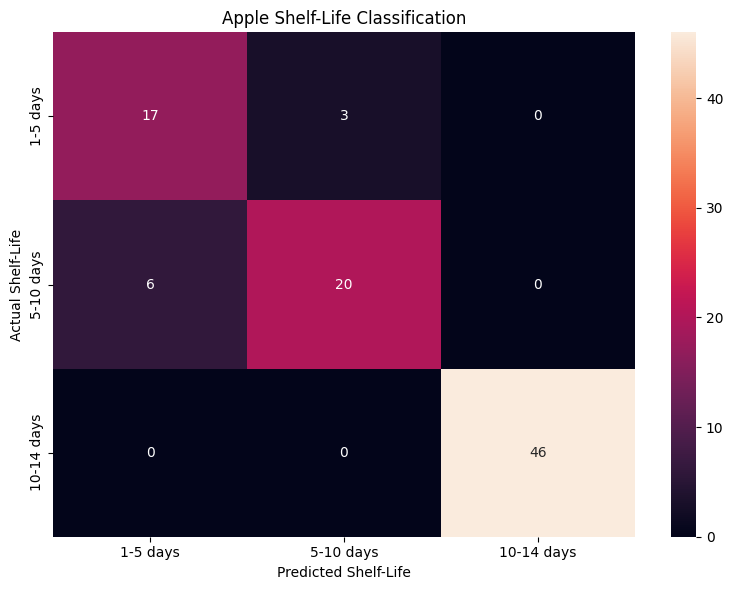

In [9]:
# CONFUSION MATRIX

cm = confusion_matrix(
    all_actual,
    all_predictions
)


plt.figure(
    figsize=(8, 6)
)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES
)


plt.xlabel(
    "Predicted Shelf-Life"
)


plt.ylabel(
    "Actual Shelf-Life"
)


plt.title(
    "Apple Shelf-Life Classification"
)


plt.tight_layout()

plt.show()

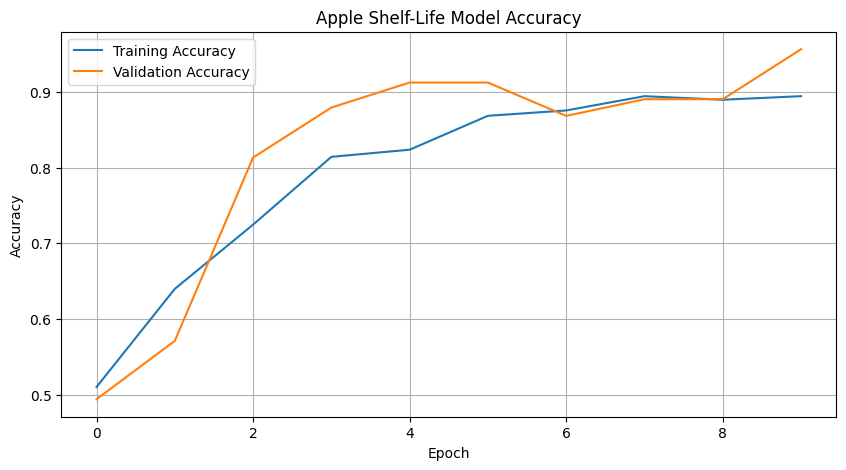

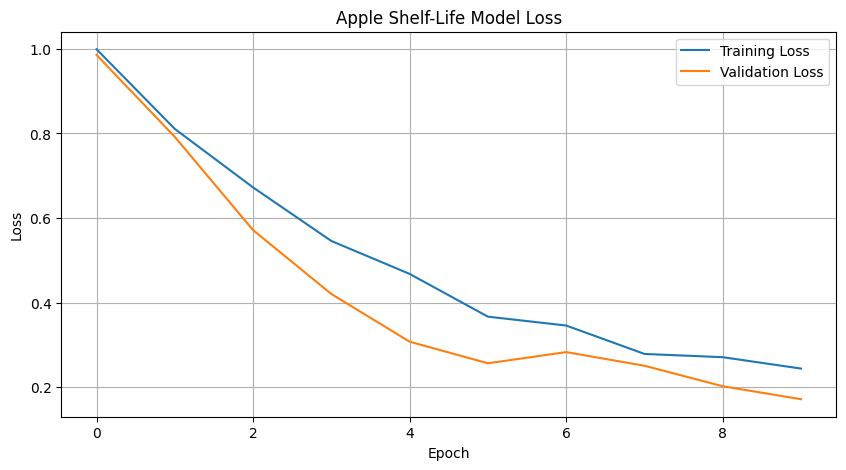

In [10]:
# ACCURACY CURVE

plt.figure(
    figsize=(10, 5)
)


plt.plot(

    history["train_accuracy"],

    label="Training Accuracy"
)


plt.plot(

    history["val_accuracy"],

    label="Validation Accuracy"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "Apple Shelf-Life Model Accuracy"
)


plt.legend()

plt.grid()

plt.show()


# LOSS CURVE

plt.figure(
    figsize=(10, 5)
)


plt.plot(

    history["train_loss"],

    label="Training Loss"
)


plt.plot(

    history["val_loss"],

    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "Apple Shelf-Life Model Loss"
)


plt.legend()

plt.grid()

plt.show()

In [13]:
# PREDICT ONE IMAGE

def predict_shelf_life(
    image_path
):


    image = Image.open(
        image_path
    ).convert("RGB")


    image_tensor = test_transform(
        image
    )


    image_tensor = image_tensor.unsqueeze(
        0
    )


    image_tensor = image_tensor.to(
        DEVICE
    )


    model.eval()


    with torch.no_grad():


        output = model(
            image_tensor
        )


        probabilities = torch.softmax(
            output,
            dim=1
        )


        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )


    predicted_class = (
        CLASS_NAMES[
            prediction.item()
        ]
    )


    confidence_value = (
        confidence.item()
    )


    return (
        predicted_class,
        confidence_value,
        probabilities.squeeze().cpu().numpy()
    )


# TEST IMAGE

IMAGE_PATH = r"C:\major-project\model\notebook\images (1).jpg"


result, confidence, probabilities = (
    predict_shelf_life(
        IMAGE_PATH
    )
)


print("=" * 60)

print("SHELF-LIFE PREDICTION")

print("=" * 60)

print(
    "Prediction:",
    result
)

print(
    f"Confidence: "
    f"{confidence * 100:.2f}%"
)


print("\nClass probabilities:")

for class_name, probability in zip(
    CLASS_NAMES,
    probabilities
):

    print(
        f"{class_name}: "
        f"{probability * 100:.2f}%"
    )

SHELF-LIFE PREDICTION
Prediction: 1-5 days
Confidence: 75.23%

Class probabilities:
1-5 days: 75.23%
5-10 days: 22.04%
10-14 days: 2.73%
